# Understanding Logistic Regression through **Perceptron Trick**

### Creating data

In [1]:
import numpy as np
from sklearn.datasets import make_classification

In [25]:
x, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0,
                          n_classes=2, n_clusters_per_class=1, random_state=41, hypercube=False, class_sep=10)

In [30]:
x[:5]

array([[ 0.19924745, -0.11697552],
       [-0.24882029, -0.73115232],
       [-0.3544904 , -0.7081059 ],
       [-1.59086506, -2.01199214],
       [-0.20083951,  1.63493163]])

### Plotting data

In [92]:
import matplotlib.pyplot as plt

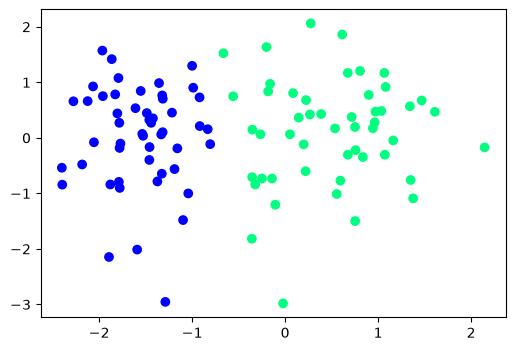

In [27]:
plt.figure(figsize=(6,4))
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='winter')

In [37]:
np.insert(x, 0, 1, axis=1)[:5]

array([[ 1.        ,  0.19924745, -0.11697552],
       [ 1.        , -0.24882029, -0.73115232],
       [ 1.        , -0.3544904 , -0.7081059 ],
       [ 1.        , -1.59086506, -2.01199214],
       [ 1.        , -0.20083951,  1.63493163]])

### Defining our Algorithm

In [39]:
def perceptron(x, y):
    x = np.insert(x, 0, 1, axis=1)
    weights = np.ones(x.shape[1])
    lr = 0.01

    for _ in range(1000):
        random_point = np.random.randint(0, 100)
        y_hat = step(np.dot(x[random_point], weights))
        weights = weights + lr*(y[random_point]-y_hat)*x[random_point]

    return weights[0], weights[1:]

In [40]:
def step(z):
    return 0 if z<0 else 1

In [41]:
intercept_, coef_ = perceptron(x, y)

In [44]:
print(coef_)
print(intercept_)

[1.28462028 0.25867325]
0.94


### Plotting our model

In [45]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [46]:
x_input = np.linspace(-3, 3, 100)
y_input = m*x_input + b

(-3.0, 2.0)

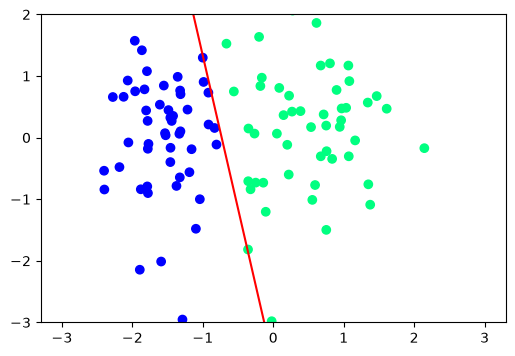

In [52]:
plt.figure(figsize=(6,4))
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='winter')
plt.plot(x_input, y_input, c='red')
plt.ylim(-3, 2)

### Animate how the actual model got

In [68]:
def new_perceptron(x,y):
    
    m = []
    b = []
    
    x = np.insert(x,0,1,axis=1)
    weights = np.ones(x.shape[1])
    lr = 0.05
    
    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(x[j],weights))
        weights = weights + lr*(y[j]-y_hat)*x[j]
        
        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))
        
    return m,b

In [69]:
m, b = new_perceptron(x, y)

In [90]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [75]:
fig, ax = plt.subplots(figsize=(6,4))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] + b[0]
ax.scatter(x[:,0],x[:,1],c=y,cmap='winter')
line, = ax.plot(x_i, y_i, 'r-')
plt.ylim(-3,3)
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)

from IPython.display import HTML
HTML(anim.to_jshtml())

<IPython.core.display.Javascript object>

### Using Logistic Regression from scikit-learn

In [77]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()

In [94]:
log_reg.fit(x, y)

print(log_reg.coef_)
print(log_reg.intercept_)

[[3.50144121 0.02773483]]
[2.25106636]


In [101]:
m = -(log_reg.coef_[0][0]/log_reg.coef_[0][1])
b = -(log_reg.intercept_[0]/log_reg.coef_[0][1])

In [102]:
x_input1 = np.linspace(-3, 3, 100)
y_input1 = m*x_input + b

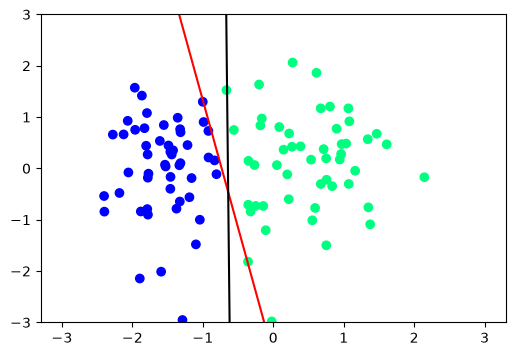

In [105]:
%matplotlib inline

plt.figure(figsize=(6, 4))
plt.scatter(x[:,0], x[:,1], c=y, cmap='winter')
plt.plot(x_input, y_input, c='red')
plt.plot(x_input1, y_input1, c='black')
plt.ylim(-3, 3)
plt.show()